## Cell 1 — Shared Imports

Loads the core Python utilities and scikit-learn metrics used throughout the notebook.

In [1]:
# ============================================================
# CELL 1: SHARED IMPORTS
# ============================================================
%matplotlib inline

# Import root = bank_pipeline, data
import os, sys
from pathlib import Path

BANK_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "bank_pipeline"), None
)
if BANK_ROOT is None:
    raise RuntimeError(f"bank_pipeline/ not found above {Path.cwd()}")
os.chdir(BANK_ROOT)
if str(BANK_ROOT) not in sys.path:
    sys.path.insert(0, str(BANK_ROOT))

print(f"📁 import root : {BANK_ROOT}")
print(f"📂 working dir : {Path.cwd()}")
for pkg in ("data", "shared", "glass_pipeline"):
    print(f"   {'✅' if (BANK_ROOT / pkg).is_dir() else '❌ MISSING'} {pkg}/")

# Core
import pandas as pd

📁 import root : c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline
📂 working dir : c:\Users\phill\projects\ai-business-coach\prototype\bank_pipeline
   ✅ data/
   ✅ shared/
   ✅ glass_pipeline/


## Cell 2 — Build Database and Preprocess

Builds the local database, then applies the leakage-aware bank preprocessing pipeline with leaky features removed.

In [2]:
# ============================================================
# CELL 2: BUILD DATABASE & PREPROCESS
# ============================================================
from data.preprocessing import BankPreprocessor, build_database

build_database()

preprocessor = BankPreprocessor(drop_leaky=True)
df_processed = preprocessor.fit_transform()


🔧  PREPROCESSING: Bank Marketing Dataset
✅  y  →  {0: 36548, 1: 4640}
✅  binary [default, housing, loan]  (unknown=-1)
✅  contact
✅  month  →  [np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7), np.int8(8), np.int8(9), np.int8(10), np.int8(11), np.int8(12)]
✅  day_of_week
✅  poutcome
✅  education  (ordinal 0-6, unknown=-1)
✅  job  →  12 categories  (unseen → -1)
✅  marital
✅  economic features  →  float64
✅  campaign features  →  unchanged numeric
⚠️   dropped leaky features: ['duration', 'pdays', 'poutcome']

✅  df_processed ready — shape: (41188, 18)
    memory: 2.91 MB



## Cell 2B — Validate Preprocessing

Runs the same preprocessing directly from the raw CSV and verifies that it produces the same dataset as the database-backed pipeline.

In [3]:
# ============================================================
# CELL 2B: VALIDATING DATA
# ============================================================
df = pd.read_csv("./data/raw/bank-additional-full.csv", sep=";")
df_csv = BankPreprocessor(drop_leaky=True, verbose=False).fit_transform(df)

print(f"Raw CSV       : {df.shape}")
print(f"From database : {df_processed.shape}")
print(f"From CSV      : {df_csv.shape}")
print(f"Identical     : {df_csv.equals(df_processed)}")

Raw CSV       : (41188, 21)
From database : (41188, 18)
From CSV      : (41188, 18)
Identical     : True


## Cell 3 — Inspect Categorical Columns

Identifies categorical features in the raw dataset and prints their observed value counts for data auditing.

In [4]:
# ============================================================
# CELL 3: EXAMINE CATAGORICAL COLUMNS
# ============================================================

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("📌 CATEGORICAL COLUMNS\n" + "-"*60)
categorical_cols

for col in categorical_cols:
    print(f"\n🔎 Column: {col}")
    print("-" * 40)

    values = (
        df[col]
        .astype(str)
        .value_counts(dropna=False)
        .sort_index()
    )

    print(values)


📌 CATEGORICAL COLUMNS
------------------------------------------------------------

🔎 Column: job
----------------------------------------
job
admin.           10422
blue-collar       9254
entrepreneur      1456
housemaid         1060
management        2924
retired           1720
self-employed     1421
services          3969
student            875
technician        6743
unemployed        1014
unknown            330
Name: count, dtype: int64

🔎 Column: marital
----------------------------------------
marital
divorced     4612
married     24928
single      11568
unknown        80
Name: count, dtype: int64

🔎 Column: education
----------------------------------------
education
basic.4y                4176
basic.6y                2292
basic.9y                6045
high.school             9515
illiterate                18
professional.course     5243
university.degree      12168
unknown                 1731
Name: count, dtype: int64

🔎 Column: default
----------------------------------------

## Cell 4 — Global Train/Test Split

Creates the shared 80/20 train/test split used across all cascade stages with a fixed random seed for reproducibility.

In [5]:
# ============================================================
# CELL 4: GLOBAL TRAIN / TEST SPLIT
# ============================================================
from data.global_splits.split_manager import GlobalSplitManager

manager = GlobalSplitManager(test_size=0.20, random_state=42)
GLOBAL_SPLIT = manager.create_split(df_processed, target_col='y')

X_train = GLOBAL_SPLIT['X_train']
X_test = GLOBAL_SPLIT['X_test']
y_train = GLOBAL_SPLIT['y_train']
y_test = GLOBAL_SPLIT['y_test']


📐  CREATING GLOBAL TRAIN / TEST SPLIT
    total samples : 41188
    positive rate : 0.1127
    features      : 17

✅  train : (32950, 17)  |  positive rate: 0.1127
    test  : (8238, 17)  |  positive rate: 0.1126
🔒  no train/test leakage

📦  GLOBAL_SPLIT ready


## Cell 5 — Feature Engineering (LR Stage 1)

Builds the three Stage 1 features shared by both arms (`LR_FEATURES` = `STAGE1_FEATURES`), from `glass_pipeline/lr/feature_engineering.py`.

| Feature | What it is | Uses labels? |
|---|---|---|
| `cellular_crisis` | 1 if contacted by cellular **and** `euribor3m < 1.5` (or both macro conditions hold) | No |
| `euribor3m_local_rate` | Train subscription rate within the row's `euribor3m` quantile bin (20 bins, unsmoothed) | Yes — fitted on train |
| `dow_month_encoded` | Smoothed train subscription rate for the row's day-of-week × month cell (λ = 100) | Yes — fitted on train |

**Leakage status.** Both encoders are fitted on `X_train` / `y_train` only; test rows are mapped through the stored bins and cells (no fallbacks on this split). They are fitted on **all** training rows before any fold split, so each training row's own label contributes to two of its features (audit F2). Aggregate check: the CV→test ROC-AUC gap matches the no-encoding baseline, so no optimism is detectable overall; a per-row, fold-refit check is still open.

**Scope.** `euribor3m` falls almost monotonically over the campaign window, so the two encoded features are effectively period-level subscription rates. Valid under the random split used here; not a forward-looking (deployment) claim (audit F21).

In [6]:

# ============================================================
# CELL 5: FEATURE ENGINEERING — LR STAGE 1
# ============================================================
# Source: prototype/glass_pipeline/lr/feature_engineering.py
#
# Produces (3 columns):
#   LIVE  cellular_crisis       — no target used; safe on any split
#   LIVE  euribor3m_local_rate  — fitted on X_train only 
#   LIVE  dow_month_encoded     — fitted on X_train + y_train 
# ============================================================
from glass_pipeline.lr.feature_engineering import engineer_features

X_train_eng, X_test_eng, engineer = engineer_features(
    X_train, X_test, y_train
)


🔧 FITTING LR FEATURE ENGINEER

📐 euribor3m_local_rate:
   Bins fitted : 20
   Rate range  : [0.0247, 0.4814]

📐 dow_month_encoded:
   Global mean  : 0.1127
   Cells fitted : 50
   Encoded range: [0.0563, 0.3539]

✅ LR feature engineer fitted.

✅ cellular_crisis: 9,735 positives (29.5%)
✅ euribor3m_local_rate: range [0.0247, 0.4814]
✅ dow_month_encoded: all cells mapped

✅ cellular_crisis: 2,433 positives (29.5%)
✅ euribor3m_local_rate: range [0.0247, 0.4814]
✅ dow_month_encoded: all cells mapped

📋 LR FEATURE ENGINEERING SUMMARY
  Features : ['cellular_crisis', 'euribor3m_local_rate', 'dow_month_encoded']
  X_train  : (32950, 3)  |  X_test: (8238, 3)

  Train feature stats:
       cellular_crisis  euribor3m_local_rate  dow_month_encoded
count       32950.0000            32950.0000         32950.0000
mean            0.2954                0.1127             0.1036
std             0.4563                0.1238             0.0541
min             0.0000                0.0247             0.0

## Cell 6 — Baseline Logistic Regression

Trains a baseline logistic regression on the 17 pre-engineering features to establish a simple reference point before the constrained Stage 1 pipeline.

- Uses the default `0.50` decision threshold with no probability calibration.
- Reports train/test classification, ranking, and calibration metrics.
- Saves the fitted baseline artifact for later comparison.

In [7]:
# ============================================================
# CELL 6: BASELINE LR STAGE
# ============================================================
from glass_pipeline.lr.lr_stage import train_baseline_lr_stage

baseline_stage, baseline_metrics = train_baseline_lr_stage(
    X_train, X_test, y_train, y_test,
    save=True, output_dir="./models/lr"
)


🚀 TRAINING BASELINE LR STAGE
   X_train: (32950, 17)
   X_test:  (8238, 17)

🤖 LOGISTIC REGRESSION STAGE 1: Baseline

Train: (32950, 17) | Positive rate: 0.1127
Features: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

📏 Scaling features...

🤖 Training Logistic Regression...

📊 Training Performance:
  accuracy: 0.7510
  precision: 0.2635
  recall: 0.6740
  f1: 0.3789
  roc_auc: 0.7729

📊 EVALUATING LR STAGE ON TEST SET (threshold=0.50, uncalibrated)

📊 Test Performance:
  Accuracy: 0.7628
  Precision: 0.2813
  Recall: 0.7112
  F1: 0.4032
  F2: 0.5447
  Roc_auc: 0.7840
  Pr_auc: 0.3958
  Brier: 0.1750
  Ece: 0.2934
  Pred_pos_rate: 0.2848

📊 Confusion Matrix:
  TN: 5624, FP: 1686
  FN: 268, TP: 660

📊 Feature Importance (Top 10):
       feature  coefficient  abs_coefficient
  emp.var.rate    -1.329841         1.329841
cons.price

## Cell 7 — Correlation Analysis and Pruning

Checks the three engineered Stage 1 features for pairwise multicollinearity before LR tuning.

- Ranks features by absolute correlation with the target.
- Flags feature pairs above the configured `|r| > 0.70` threshold.
- Drops redundant features only when that threshold is exceeded.
- Visualizes the resulting correlation matrix.


📊 Generating correlation heatmap (original features)...


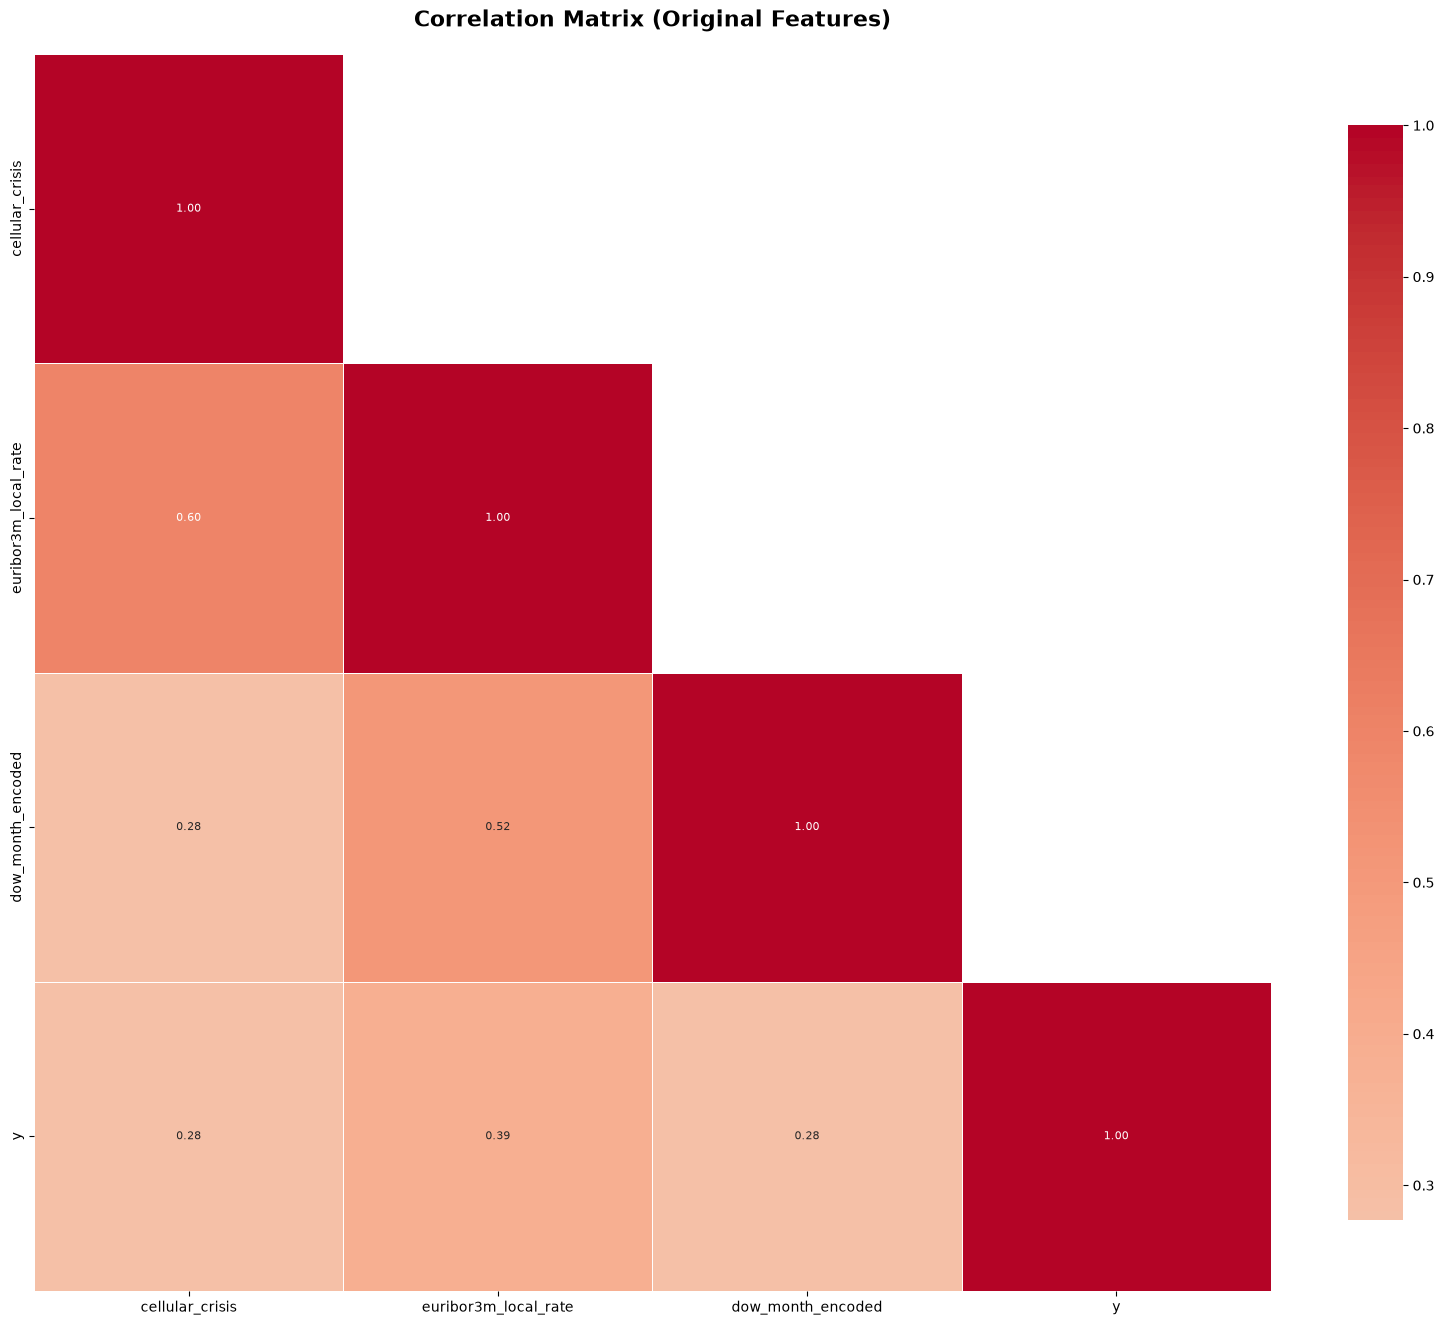


🔍 CORRELATION ANALYSIS & MULTICOLLINEARITY REDUCTION

📈 Top 10 features by |correlation| with target:
  euribor3m_local_rate: 0.3915
  dow_month_encoded: 0.2774
  cellular_crisis: 0.2771

✅ No feature pairs with |r| > 0.7

📋 MULTICOLLINEARITY REDUCTION SUMMARY
  Correlation threshold: |r| > 0.7
  High-corr pairs found: 0
  Features dropped: 0
  Original feature count: 3
  Final feature count: 3


In [8]:
# ============================================================
# CELL 7: CORRELATION ANALYSIS & PRUNING
# ============================================================
from glass_pipeline.lr.correlation_analysis import analyze_and_prune_features

X_train_pruned, X_test_pruned, analyzer = analyze_and_prune_features(
    X_train_eng, X_test_eng, y_train,
    threshold=0.7,
    plot=True
)

    

## Cell 8 — Tuned and Calibrated Stage 1 LR

Trains the production Stage 1 logistic regression on the three engineered features using the full training-only tuning and calibration procedure.

- Tunes LR hyperparameters by cross-validation.
- Selects and fits probability calibration; isotonic regression is chosen here.
- Generates out-of-fold training probabilities.
- Selects the operating threshold from OOF predictions using F2.
- Evaluates the finalized model once on the held-out test set.
- Saves the Stage 1 artifact for downstream cascade use.

The selected threshold is `0.110`, with test ROC-AUC `0.7893`, F2 `0.5597`, and ECE `0.0078`.

📈 STAGE 1: CALIBRATED LOGISTIC REGRESSION

🚀 TRAINING LR STAGE (FULL GLOBAL_SPLIT, NO INTERNAL SPLIT)
   X_train: (32950, 3)
   X_test:  (8238, 3)

🔧 CALIBRATED LR STAGE: Optuna Tuning (balanced) + Calibration

📏 Scaling features...

🧠 HYPERPARAMETER TUNING — Optuna (ROC-AUC, balanced)


  0%|          | 0/100 [00:00<?, ?it/s]


✅ Best Parameters (ROC-AUC=0.779616, 39.5s):
   C            = 0.397778
   penalty      = elasticnet
   l1_ratio     = 0.1705
   class_weight = balanced  |  solver = saga
   Trials: 59 completed, 41 pruned

🔧 PROBABILITY CALIBRATION

📊 Uncalibrated Metrics:
   Brier: 0.173819
   ECE:   0.290029

   Fitting Platt Scaling (sigmoid)...
   Fitting Isotonic Regression...

🏆 Selected Calibration: isotonic
   Brier: 0.173819 → 0.082684
   ECE:   0.290029 → 0.002633

🎯 Computing OOF probabilities and optimizing threshold...
   Optimal threshold (CV): 0.1100
   CV F2-score:            0.5368
   OOF provenance:         refittable (cv=10)

📈 EVALUATING CALIBRATED LR (threshold=0.1100)

📊 Test Performance:
   ACCURACY: 0.8094
   PRECISION: 0.3309
   RECALL: 0.6767
   F1: 0.4444
   F2: 0.5597
   ROC_AUC: 0.7893
   PR_AUC: 0.3877
   BRIER: 0.0811
   ECE: 0.0078
   PRED_POS_RATE: 0.2304

📊 Confusion Matrix:
   TN: 6040, FP: 1270
   FN: 300, TP: 628


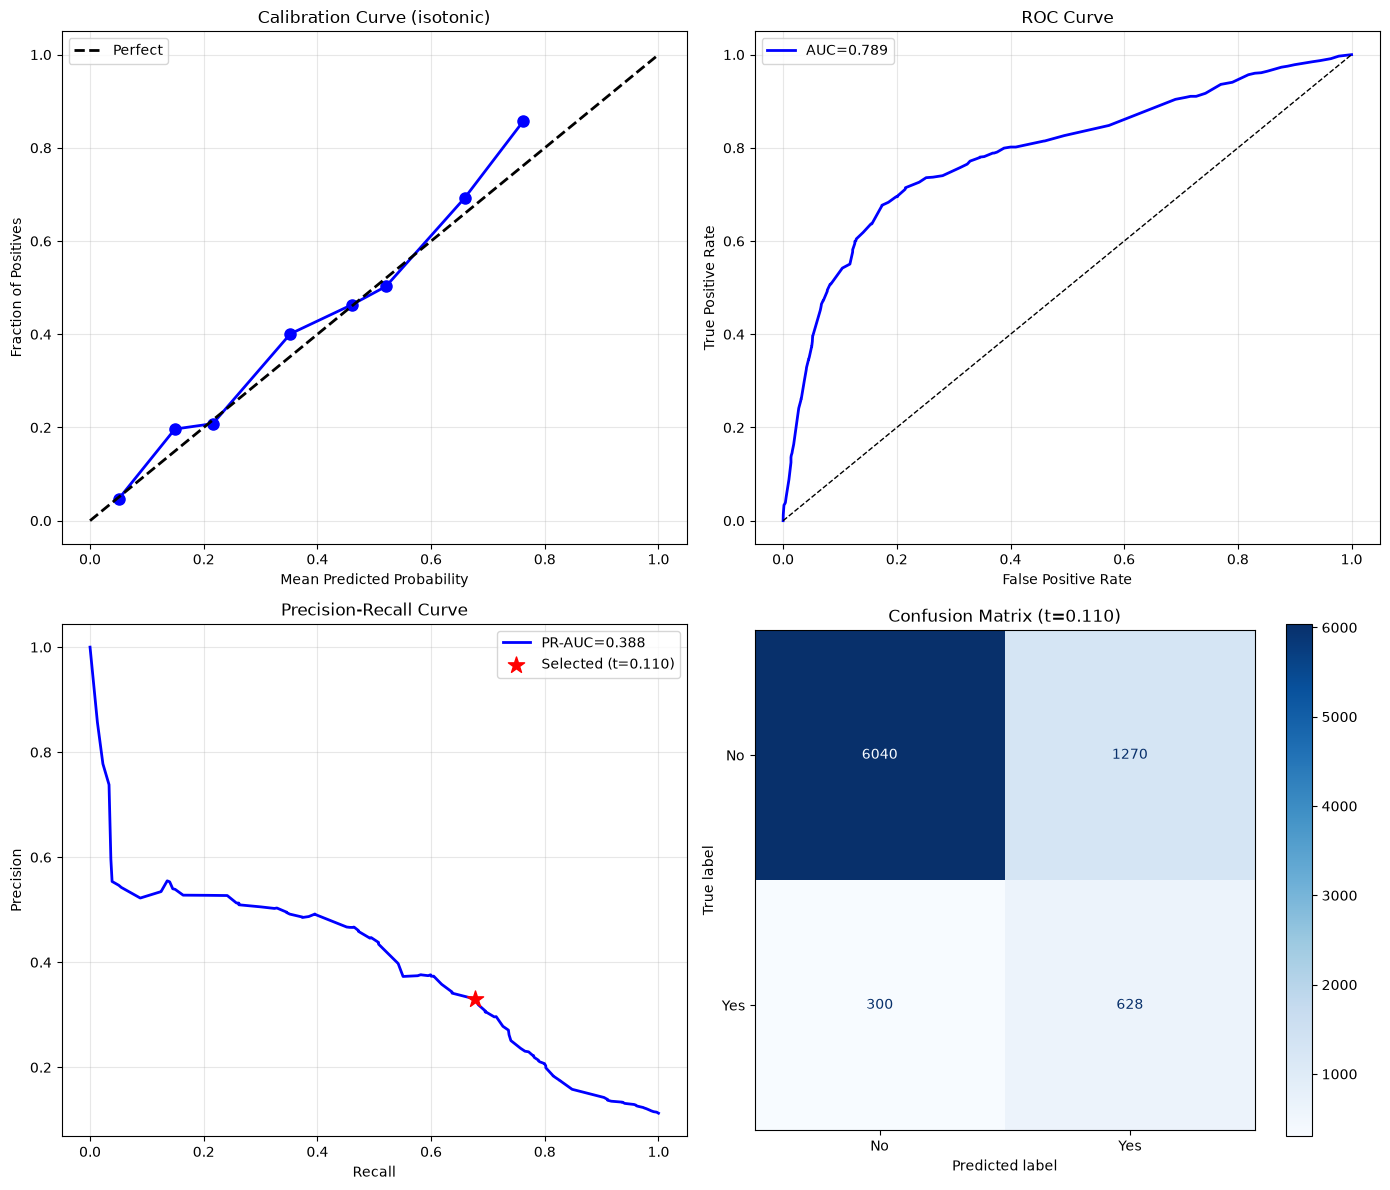


📊 Feature Importance (Top 10):
             feature  coefficient  abs_coefficient
euribor3m_local_rate     0.579018         0.579018
     cellular_crisis     0.317543         0.317543
   dow_month_encoded     0.276260         0.276260

💾 Saving LR artifact (v2.0)...
   train_proba_oof : 32950 samples (out-of-fold)
   test_proba      : 8238 samples
   threshold       : 0.1100 [in_stage_f2_cv]
   ✅ Saved → ./models/lr\lr_calibrated_20260924_114605.joblib

🎯 LR Stage complete

✅ LR Stage 1 complete
📦 Saved artifact → ./models/lr\lr_calibrated_20260924_114605.joblib
📊 Test ROC-AUC: 0.7893
📊 Test F1:      0.4444
📊 Test F2:      0.5597
📊 ECE:          0.0078


In [9]:
# ============================================================
# CELL 8: LR TUNING + CALIBRATION
# ============================================================
from glass_pipeline.lr.lr_stage_calibrated import train_calibrated_lr_stage

print("=" * 80)
print("📈 STAGE 1: CALIBRATED LOGISTIC REGRESSION")
print("=" * 80)

lr_calibrated_artifact, lr_calibrated_path = train_calibrated_lr_stage(
    X_train_eng, X_test_eng,
    y_train, y_test,
    save=True,
    output_dir="./models/lr"
)

print(f"\n✅ LR Stage 1 complete")
print(f"📦 Saved artifact → {lr_calibrated_path}")
print(f"📊 Test ROC-AUC: {lr_calibrated_artifact.metrics['roc_auc']:.4f}")
print(f"📊 Test F1:      {lr_calibrated_artifact.metrics['f1']:.4f}")
print(f"📊 Test F2:      {lr_calibrated_artifact.metrics['f2']:.4f}")
print(f"📊 ECE:          {lr_calibrated_artifact.metrics['ece']:.4f}")

## Cell 9 — RF Lift Analysis

Runs an exploratory Random Forest analysis to inspect predictive importance and conversion-rate lift.

- Reports Gini and permutation importance.
- Measures continuous and categorical feature lift relative to the training base rate.
- Visualizes conversion-rate patterns across feature values.

🌲 RF LIFT ANALYSIS

🌲 Training Random Forest...
   Accuracy: 0.8461
   ROC-AUC:  0.8102

📊 FEATURE IMPORTANCE ANALYSIS

🔝 Gini Importance (Top 15):
       Feature  Gini_Importance
   nr.employed         0.272092
     euribor3m         0.231842
  emp.var.rate         0.152457
 cons.conf.idx         0.082013
cons.price.idx         0.057881
         month         0.047519
      previous         0.031056
           age         0.028517
       contact         0.024014
      campaign         0.016102
   day_of_week         0.015164
     education         0.010295
           job         0.010187
       default         0.009355
       marital         0.005425

🔀 Computing Permutation Importance...

🔝 Permutation Importance (Top 15):
       Feature  Perm_Importance  Perm_Std
  emp.var.rate         0.017898  0.003431
     euribor3m         0.016695  0.002672
   nr.employed         0.016498  0.003402
       contact         0.010539  0.002355
cons.price.idx         0.004856  0.001788
 cons.conf.id

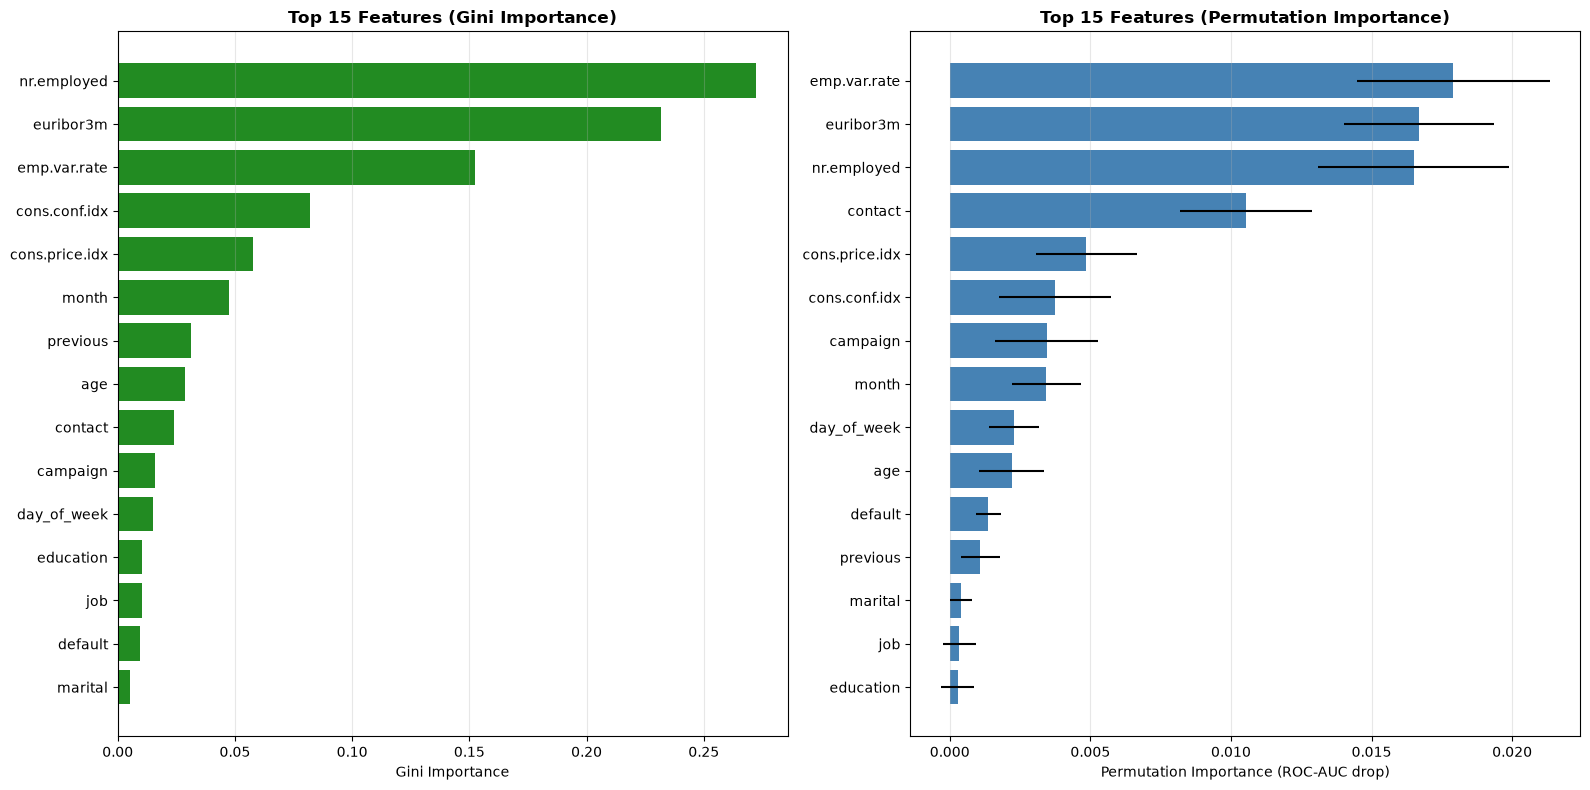

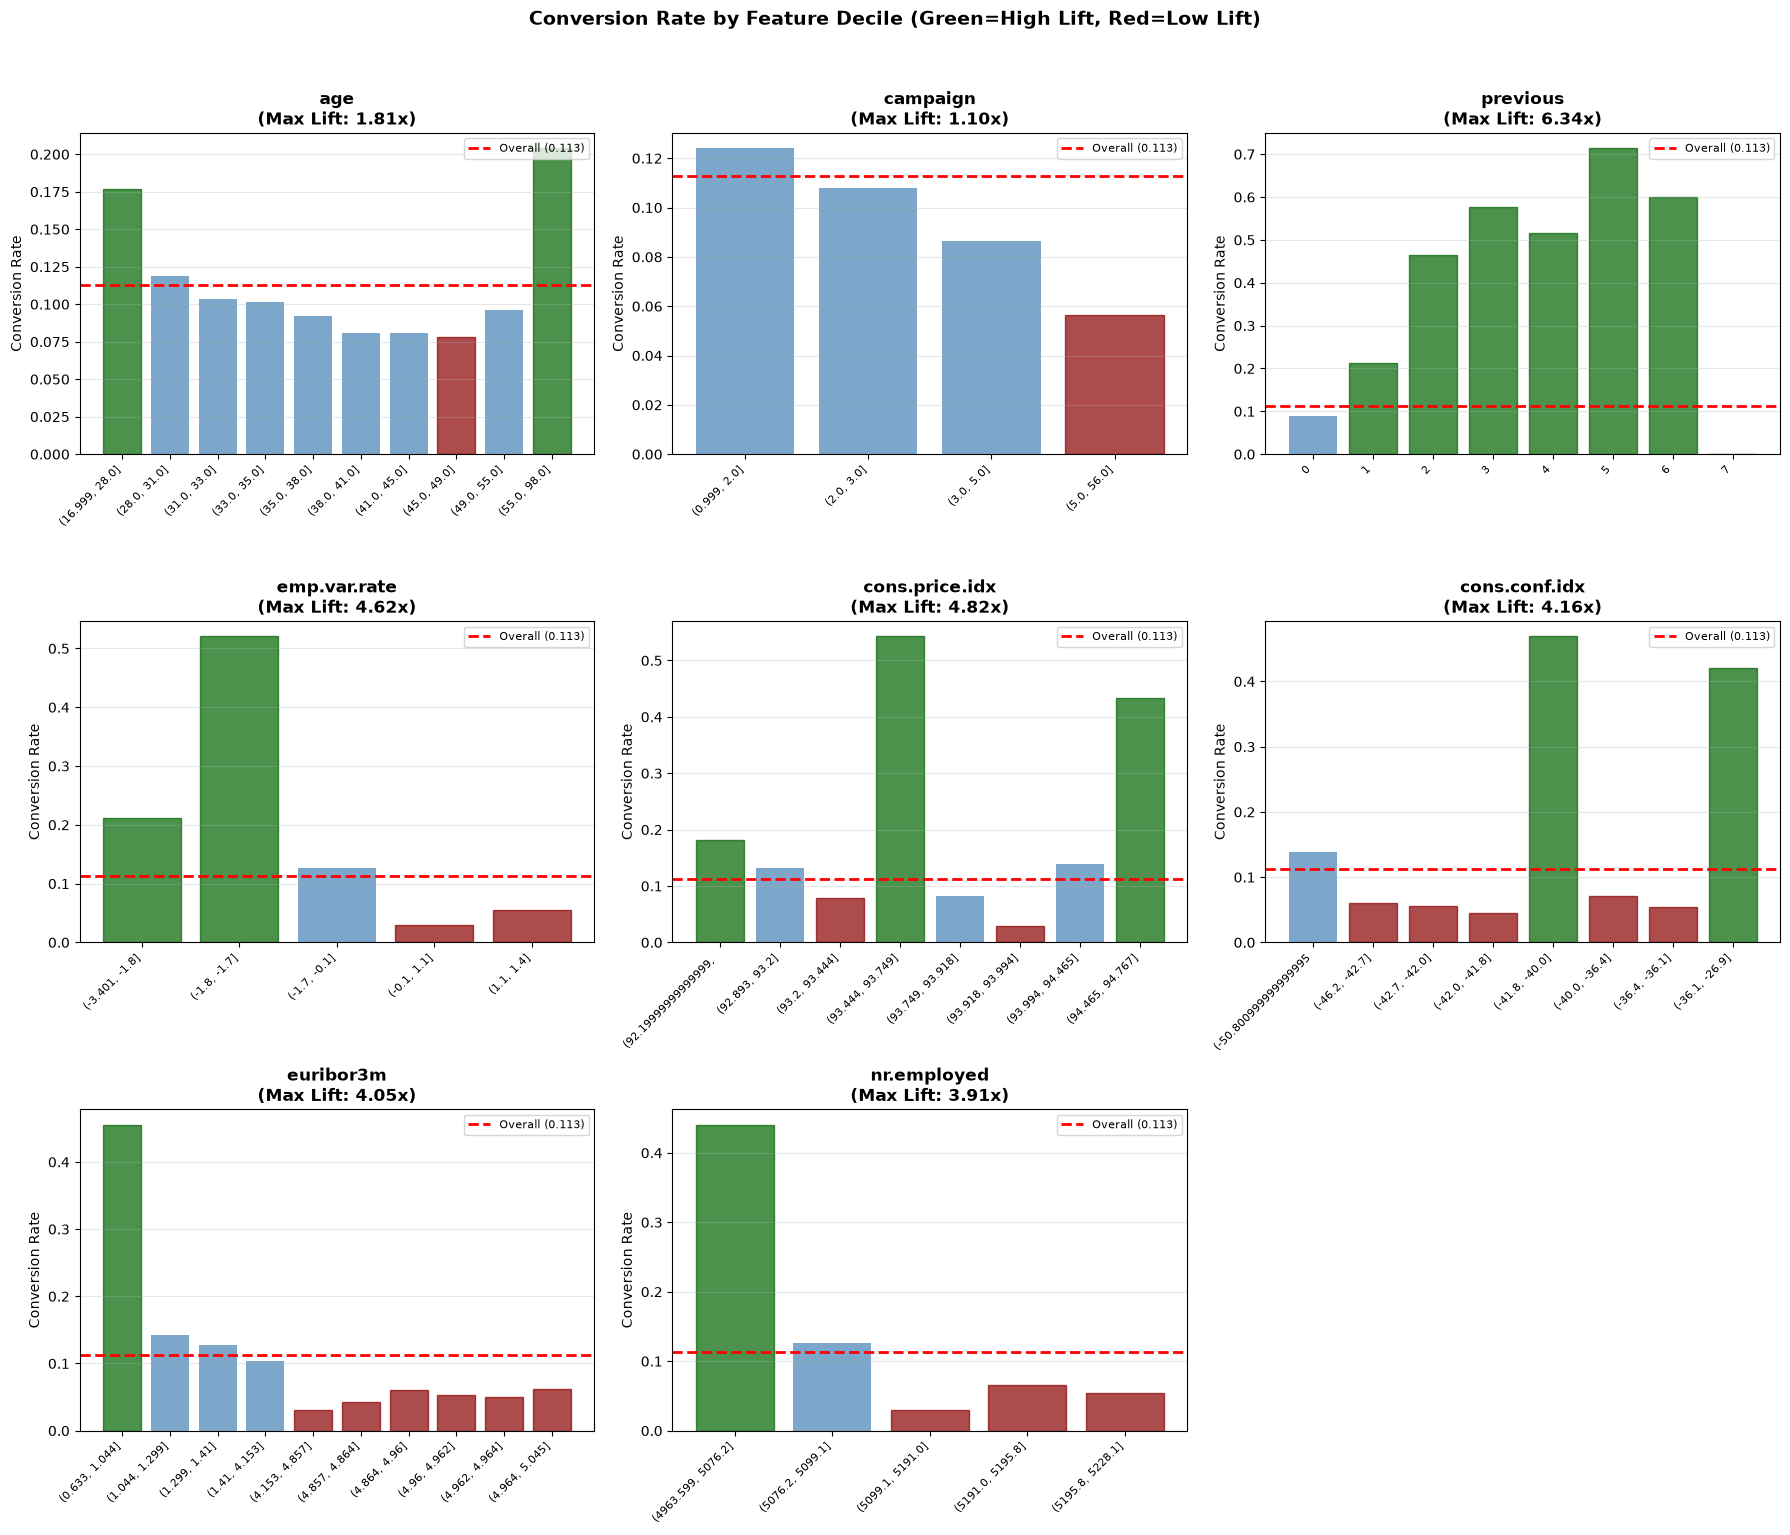


🎯 Use these insights to define GLASS Router binning


In [10]:
# ============================================================
# CELL 9: RF LIFT ANALYSIS 
# ============================================================
# Note: permutation importance inside analyze_rf_lift is scored on X_test.
# Do not use its rankings to change bins or features.
from glass_pipeline.glass_router.rf import analyze_rf_lift

rf_analyzer, rf_analysis = analyze_rf_lift(
    X_train, y_train,
    X_test,  y_test,
    plot=True,
)

## Cell 10 — GLASS Router Feature Engineering

Builds the binary feature representation used by the Stage 2 GLASS Router.

- Constructs 8 continuous source features.
- Encodes them into 29 lift-driven binary bins.
- Applies the same feature transformation to train and test data.
- Validates binary values, mutually exclusive groups, and activation patterns.
- Stores the resulting frames and metadata in `GLASS_ROUTER_DATA`.

In [11]:
# ============================================================
# CELL 10: GLASS ROUTER FEATURE ENGINEERING (full train → test)
# ============================================================
from glass_pipeline.glass_router.rf import engineer_features

X_train_eng, X_test_eng = engineer_features(X_train, X_test, y_train)

GLASS_ROUTER_DATA = {
    "X_eng_train":   X_train_eng,
    "y_eng_train":   y_train,
    "X_eng_test":    X_test_eng,
    "y_eng_test":    y_test,
    "feature_names": list(X_train_eng.columns),
}

🔧 CELL 10: RF STAGE 2 FEATURE ENGINEERING

[1/3] Building 8 continuous source features...
      Train: (32950, 8) | NaNs: 0
      Test:  (8238, 8)  | NaNs: 0

[2/3] Binning to 29 binary features...

🔀 FEATURE BINNING — LIFT-DRIVEN MULTI-BIN ENCODING
   Converting source features → 29 binary bins
────────────────────────────────────────────────────────────────────────────────

   Per-bin lift (base rate: 0.1127):
   Bin                                N     Conv    Lift
   ---------------------------- ------- -------- -------
   nsd_cold                      22,120   0.0493   0.44x 🔴
   nsd_warm                       6,839   0.1262   1.12x   
   nsd_elevated                   1,326   0.3522   3.13x 🔥
   nsd_hot                        2,665   0.4848   4.30x 🔥
   jed_cold                      19,283   0.0492   0.44x 🔴
   jed_transition                 3,505   0.0899   0.80x   
   jed_warm                       6,849   0.1368   1.21x   
   jed_hot                        3,313   0.4564   4.0

## Cell 11 — Stage 2 RF Baseline

Trains a fixed-parameter Random Forest on the 29 binary Stage 2 features as a reference model.

- Uses the same engineered feature representation as the GLASS Router.
- Performs no hyperparameter tuning.
- Reports held-out classification, ranking, and calibration metrics.

In [12]:
# ============================================================
# CELL 11: RF BASELINE (default params, binary features)
# ============================================================
from glass_pipeline.glass_router.rf import train_rf_baseline

baseline_metrics = train_rf_baseline(
    GLASS_ROUTER_DATA["X_eng_train"], GLASS_ROUTER_DATA["X_eng_test"],
    GLASS_ROUTER_DATA["y_eng_train"], GLASS_ROUTER_DATA["y_eng_test"],
)


🌲 RF STAGE 2 — BASELINE (default params, no tuning)
   n_estimators=200 | max_depth=10 | min_samples_leaf=50 | class_weight=balanced

   Accuracy  : 0.8358
   ROC-AUC   : 0.7977
   Precision : 0.3679
   Recall    : 0.6379
   F1        : 0.4667
   Brier     : 0.1640


## CELL 12 — Stage 2 Optuna Training

Tunes the Random Forest on the 29 engineered binary features with 200 Optuna trials, evaluates it with 10-fold CV, selects an OOF F2 threshold, then refits on the full training set for held-out test evaluation.

`baseline_auc` is used only for comparison reporting.

In [13]:
# ============================================================
# CELL 12: RF STAGE 2 — OPTUNA TRAINING
# ============================================================
from glass_pipeline.glass_router.rf import train_rf_stage

rf_result = train_rf_stage(
    GLASS_ROUTER_DATA["X_eng_train"], GLASS_ROUTER_DATA["X_eng_test"],
    GLASS_ROUTER_DATA["y_eng_train"], GLASS_ROUTER_DATA["y_eng_test"],
    n_trials=200,
    baseline_auc=baseline_metrics["roc_auc"],
)


🌲 RF STAGE 2 — BAYESIAN OPTIMIZATION (BINARY FEATURES)

📊 Dataset     : 32,950 train | 8,238 test | 29 binary features
   Feature space: 2^29 = 536,870,912 possible patterns
   Observed     : 397 patterns
   Class dist   : {0: 29238, 1: 3712}

🔍 Pre-flight validation...
   ✅ All values binary, no missing data

────────────────────────────────────────────────────────────────────────────────
🧠 Bayesian Optimization — 200 trials, 5-fold CV
   class_weight=balanced (fixed) | minority_weight in [1.0, 3.0]
────────────────────────────────────────────────────────────────────────────────


  0%|          | 0/200 [00:00<?, ?it/s]


   ✅ Tuning complete in 6211.0s
   Trials : 75 completed | 125 pruned
   Best Optuna AUC : 0.787140

   Best params:
              n_estimators = 650
                 max_depth = 6
          min_samples_leaf = 12
              max_features = 0.3999
           minority_weight = 1.3001
              class_weight = balanced

────────────────────────────────────────────────────────────────────────────────
📊 10-Fold CV Evaluation with best params...
────────────────────────────────────────────────────────────────────────────────
   AUC       : 0.7875 ± 0.0154
   Recall    : 0.5816 ± 0.0259
   Precision : 0.4002 ± 0.0191
   F1        : 0.4739 ± 0.0182
   R@10%FPR  : 0.5738

   vs baseline : 0.7977 → -0.0101 ↓

────────────────────────────────────────────────────────────────────────────────
🎯 Selecting operating threshold from OOF predictions...
────────────────────────────────────────────────────────────────────────────────
   OOF threshold : 0.4600
   OOF F2        : 0.5371

   Refitting o

c:\Users\phill\projects\ai-business-coach\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\phill\projects\ai-business-coach\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\phill\projects\ai-business-coach\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\phill\projects\ai-busi


📊 RF STAGE 2 — TRAINING SUMMARY
   10-Fold CV AUC  : 0.7875 ± 0.0154
   R@10%FPR      : 0.5738
   Test AUC      : 0.7996
   Test Recall   : 0.6703
   Test F1       : 0.4390
   Stability     : Moderate variance
   Runtime       : 6211.0s


## Cell 12B — RF Diagnostics

Visualizes held-out test performance for the Optuna-tuned Stage 2 RF on the 29 binary features.

- ROC and precision-recall curves.
- Confusion matrix at the OOF-selected F2 operating threshold.

c:\Users\phill\projects\ai-business-coach\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\phill\projects\ai-business-coach\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\phill\projects\ai-business-coach\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\phill\projects\ai-busi

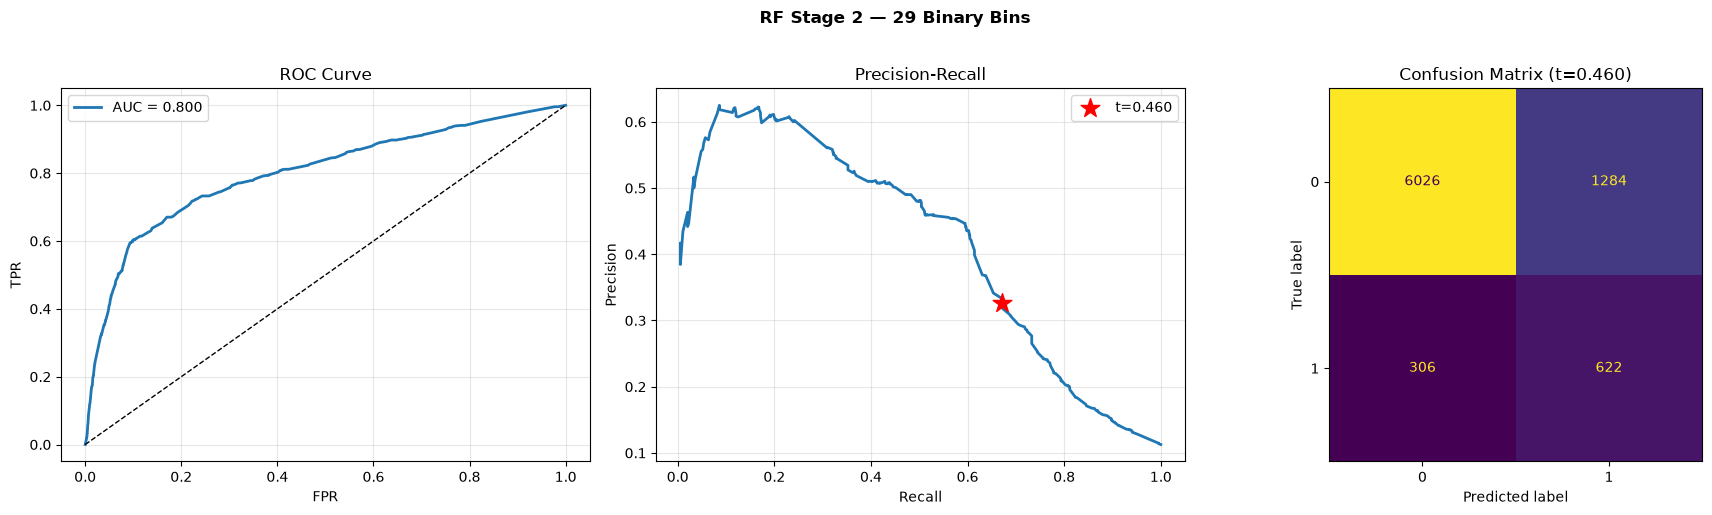

In [14]:
# ============================================================
# CELL 12B: RF DIAGNOSTICS (test set)
# ============================================================
from glass_pipeline.glass_router.rf import plot_rf_evaluation

plot_rf_evaluation(
    rf_result,
    GLASS_ROUTER_DATA["X_eng_test"],
    GLASS_ROUTER_DATA["y_eng_test"],
    threshold=rf_result.threshold,
)

## Cell 13 — GLASS Router: Fit and Test Routing

Selects a `CONFIG_PROFILE`, fits GLASS Router on the full training split, and routes the test split.

| Preset | Purpose |
|---|---|
| `legacy` | Reproduces the pre-refactor configuration. |
| `recommended` | Provisional stricter routing configuration. |

Final presets are selected later using **train OOF results only**. The black-box router matches the saved GLASS operating constraints for fair comparison.

**Outputs:** `glass`, `test_out`, `test_proba`.

In [15]:
# ============================================================
# CELL 13: GLASS ROUTER — CONFIG + FULL-TRAIN FIT + TEST ROUTING
# ============================================================
import time
from glass_pipeline.glass_router.core.config import GlassRouterConfig
from glass_pipeline.glass_router.pipeline import GlassRouterPipeline
from glass_pipeline.glass_router.rule_generator.rule_logger import RuleLogger
from glass_pipeline.glass_router.core.rule import ABSTAIN
from glass_pipeline.glass_router.model_outputs import build_glass_output

# "legacy"      = previous run's values; confirms the refactor reproduces
#                 earlier results before changing anything
# "recommended" = provisional starting point (see notes below)
CONFIG_PROFILE = "legacy"  # other presets are tried in the comparisons pipeline (PR 38)

_SHARED = dict(
    mode="strict",                   # stored only; no code path reads it yet
    max_complexity=3,
    diversity_weight=0.35,           # beam-search reuse penalty + greedy fallback
    enable_novelty_constraints=True,
    # Depth-2 light pruning: effectively off (0.90) so depth 3 does the filtering
    max_leakage_rate_depth2=0.90,
    max_leakage_fraction_depth2=0.90,
    # Required by GlassRouterConfig but not read by any code path yet
    max_jaccard_overlap=0.5,
    max_high_overlap_rules=20,
    max_feature_reuse_pass1=None,
    max_feature_reuse_pass2=None,
)

_PROFILES = {
    "legacy": dict(
        min_support_pass1=120,   min_support_pass2=25,
        min_pass1_rules=6,       max_pass1_rules=8,
        min_precision_not_subscribe=0.93, max_precision_not_subscribe=1.00,
        max_subscriber_leakage_rate=0.05, max_subscriber_leakage_absolute=800,
        min_pass2_rules=5,       max_pass2_rules=8,
        min_precision_subscribe=0.20,     max_precision_subscribe=1.00,
        min_recall_subscribe=0.01,        max_recall_subscribe=0.35,
        min_novelty_ratio_pass1=0.20,     min_novelty_ratio_pass2=0.25,
        # lambdas left unset -> ILP defaults 0.15 / 0.08
        pass2_population="full",          # original behaviour, for parity checks
    ),
    "recommended": dict(
        # Support: evaluator floor is min(pass1, pass2) // 2 = 25 rows
        min_support_pass1=150,   min_support_pass2=50,

        # Pass 1 — "precision" = share of NON-subscribers in the rule.
        min_pass1_rules=2,       max_pass1_rules=6,
        min_precision_not_subscribe=0.92, max_precision_not_subscribe=1.00,
        max_subscriber_leakage_rate=0.10, max_subscriber_leakage_absolute=500,

        # Pass 2 — precision floor 0.30 (~2.7x base rate) blocks the near-universal
        # rules the recall-first score otherwise favours.
        min_pass2_rules=3,       max_pass2_rules=10,
        min_precision_subscribe=0.30,     max_precision_subscribe=1.00,
        min_recall_subscribe=0.01,        max_recall_subscribe=0.25,

        # ILP novelty: forbid pairs where BOTH rules overlap > 80% (0.01 ≈ off).
        min_novelty_ratio_pass1=0.20,     min_novelty_ratio_pass2=0.20,

        # The evaluator never receives the RF, so every rule gets rf_confidence=0.5
        # and rf_alignment=0.0. With the defaults (0.15 / 0.08) that is a flat
        # -0.155 per selected rule, which acts as a hidden cutoff on rule quality.
        # 0.0 removes it; the ILP then ranks by rule quality alone.
        lambda_rf_uncertainty=0.0,
        lambda_rf_misalignment=0.0,

        # Pass 2 fitted on the rows Pass 1 does not route, using OUT-OF-FOLD Pass 1
        # decisions (5 inner folds) — same construction as the black-box RF router.
        pass2_population="oof_remainder",
        pass1_oof_folds=5,
        random_state=42,
        remainder_min_size=500,
    ),
}

config = GlassRouterConfig(**_SHARED, **_PROFILES[CONFIG_PROFILE])
print(f"Config profile: {CONFIG_PROFILE}\n{config}")


def make_rule_logger():
    return RuleLogger(
        enabled=False,
        verbose_rejection_logging=False,
        verbose_acceptance_logging=False,
    )


start_time = time.time()

glass = GlassRouterPipeline(
    config=config,
    rf_model=rf_result.model,        # used for feature ordering in rule generation
    rule_logger=make_rule_logger(),
)
# Rules are evaluated on the training rows (X_val = X_train). With
# pass2_population="oof_remainder", Pass 2 is fitted on the out-of-fold Pass 1
# remainder. The cross-fit in Cell 14 repeats exactly this recipe per fold.
glass.fit(
    X_train=GLASS_ROUTER_DATA["X_eng_train"],
    y_train=GLASS_ROUTER_DATA["y_eng_train"],
)

test_out = build_glass_output(glass, GLASS_ROUTER_DATA["X_eng_test"], abstain_value=ABSTAIN)
test_proba = glass.predict_proba(GLASS_ROUTER_DATA["X_eng_test"])

elapsed = time.time() - start_time
print(f"\n⏱️  GLASS Router full-train fit + test routing: {elapsed:.1f}s ({elapsed / 60:.1f} min)")

Config profile: legacy
GlassRouterConfig(mode='strict', pass1=[6-8], pass2=[5-8], complexity=3, pass2_population='full')
✅ RuleGenerator initialized with 29 segment features
   (all tuning params validated)
✅ ILPRuleSelector initialized (all tuning params validated)
✅ GlassRouterPipeline initialized

Top 10 RF features by importance:
  nsd_cold: 0.3064
  jed_hot: 0.1894
  dow_hot: 0.0836
  nsd_hot: 0.0782
  jed_cold: 0.0690
  nsd_warm: 0.0500
  behav_hot: 0.0284
  nsd_elevated: 0.0276
  cci_low: 0.0261
  jed_warm: 0.0235

Using 29/29 features above threshold

SEQUENTIAL RULE GENERATION WITH DEPTH-STAGED CONSTRAINTS
  Beam width: 100
  Complexity: 1–3
  Total samples: 32950
  Total subscribers: 3712

  ✅ DEPTH-STAGED CONSTRAINT STRATEGY:
    • Depth 1: ONLY structural validity
    • Depth 2: Light pruning ONLY
    • Depth 3: Quality constraints (NO OVERLAP - ILP handles)

DEPTH 1: SEED GENERATION
  🚫 NO support constraints at this depth
  🚫 NO precision/recall constraints at this depth


## Cell 14 — Stage 2 Cross-Fit

Generates leakage-safe Stage 2 OOF outputs for Stage 4.

- Repeats the full Stage 2 recipe within each fold.
- Reuses the tuned RF hyperparameters without re-tuning.
- Fits GLASS Router only on each fold's training partition.
- Scores every training row with models that never saw it.
- Preserves fold IDs and OOF RF/GLASS probabilities for downstream stacking.

In [16]:
# ============================================================
# CELL 14: STAGE 2 CROSS-FIT — OOF OUTPUTS FOR STAGE 4 
# ============================================================
from glass_pipeline.glass_router.pipeline import crossfit_stage2
 
STAGE_FOLDS = None
 
start_time = time.time()
stage2_oof = crossfit_stage2(
    X_train_raw=X_train,             
    y_train=y_train,
    glass_config=config,
    rf_params=rf_result.params,
    folds=STAGE_FOLDS,
    n_splits=5,
    random_state=42,
    glass_rf_model="fold_rf",        
    rule_logger_factory=make_rule_logger,
)
elapsed = time.time() - start_time
print(f"\n⏱️  Stage 2 cross-fit: {elapsed:.1f}s ({elapsed / 60:.1f} min)")

🔁 STAGE 2 CROSS-FIT — 5 folds | 32,950 training rows
   fold 0: RF AUC 0.7796 | GLASS rules 6+5 | pass1 23.9% pass2 26.0% abstain 50.1% | leak 9.7% | 53.1s
   fold 1: RF AUC 0.7950 | GLASS rules 4+5 | pass1 31.9% pass2 26.8% abstain 41.2% | leak 8.4% | 54.6s
   fold 2: RF AUC 0.7896 | GLASS rules 6+5 | pass1 39.0% pass2 26.8% abstain 34.2% | leak 16.4% | 53.3s
   fold 3: RF AUC 0.7839 | GLASS rules 6+5 | pass1 43.6% pass2 14.9% abstain 41.5% | leak 19.7% | 52.7s
   fold 4: RF AUC 0.7871 | GLASS rules 6+5 | pass1 36.4% pass2 21.8% abstain 41.8% | leak 14.3% | 52.6s
--------------------------------------------------------------------------------
   Fold fingerprint         : 8aea082fcaf371b7
   OOF RF AUC (all rows)   : 0.7863
   OOF GLASS pass1/pass2/abstain: 35.0% / 23.3% / 41.8%
   OOF GLASS Pass 1 leakage : 13.7%
   OOF GLASS Pass 2 recall  : 60.1%

⏱️  Stage 2 cross-fit: 266.5s (4.4 min)


## Cell 15 — Stage 2 Report

Compares full-train test behavior with leakage-safe train OOF behavior.

- Reports routing rates, abstention, leakage, recall, and covered metrics.
- Checks the Pass 1 leakage constraint on OOF predictions.
- Measures OOF vs in-sample optimism for GLASS Router and RF.
- Summarizes per-fold stability and selected full-train rules.
- Reports held-out test classification with abstentions mapped to `NOT_SUBSCRIBE`.

The **TRAIN OOF** column is the correct basis for configuration and Stage 4 decisions; test results remain evaluation-only.

In [17]:
# ============================================================
# CELL 15: STAGE 2 REPORT — TEST (full-train model) vs OOF (train)
# ============================================================
import pandas as pd
from sklearn.metrics import classification_report
from glass_pipeline.glass_router.core.rule import SUBSCRIBE
from glass_pipeline.glass_router.model_analysis import compute_glass_analysis_metrics
from glass_pipeline.glass_router.pipeline import oof_vs_insample
 
PASS1_LEAKAGE_TARGET = 0.10   # max share of subscribers Pass 1 may route away
 
oof_out = stage2_oof.glass_train_out()
m_test = compute_glass_analysis_metrics(glass, test_out, GLASS_ROUTER_DATA["y_eng_test"], SUBSCRIBE)
m_oof  = compute_glass_analysis_metrics(glass, oof_out,  GLASS_ROUTER_DATA["y_eng_train"], SUBSCRIBE)
 
def _flow(m):
    tp = max(m["total_positives"], 1)
    return {
        "Pass 1 routed":        m["n_pass1"] / m["n_test"],
        "Pass 2 flagged":       m["n_pass2"] / m["n_test"],
        "Abstained":            m["n_uncertain"] / m["n_test"],
        "Pass 1 leakage":       m["blocked_positives"] / tp,
        "Pass 2 recall (all)":  m["overall_recall"],
        "Pass 2 recall (elig)": m["eligible_recall"],
        "Covered precision":    m["covered_precision"],
        "Covered recall":       m["covered_recall"],
        "Covered F1":           m["covered_f1"],
    }
 
report = pd.DataFrame({"TEST (full-train model)": _flow(m_test), "TRAIN OOF": _flow(m_oof)})
print("=" * 80)
print(f"📊 STAGE 2 — GLASS ROUTER REPORT  (profile: {CONFIG_PROFILE})")
print("=" * 80)
print(f"Rules (full-train model): Pass 1 = {m_test['n_pass1_rules']} | Pass 2 = {m_test['n_pass2_rules']}")
_fr = glass.fit_report_
print(f"Pass 2 population: {_fr.get('pass2_population')}", end="")
if _fr.get("pass2_population") == "oof_remainder":
    print(f" | remainder {_fr['remainder_rows']:,} rows ({_fr['remainder_fraction']:.1%}), "
          f"base rate {_fr['remainder_base_rate']:.3f}, "
          f"inner Pass 1 rule counts {_fr['inner_pass1_rule_counts']}")
else:
    print()
print(report.map(lambda v: f"{v:.1%}").to_string())
 
leak_oof = _flow(m_oof)["Pass 1 leakage"]
print(f"\nPass 1 operating constraint (OOF): leakage {leak_oof:.1%} vs target "
      f"{PASS1_LEAKAGE_TARGET:.0%} -> {'PASS' if leak_oof <= PASS1_LEAKAGE_TARGET else 'FAIL'}")
 
# Optimism Stage 4 would inherit from in-sample train features
glass_opt = oof_vs_insample(
    y_train, stage2_oof.glass_proba[:, 1],
    glass.predict_proba(GLASS_ROUTER_DATA["X_eng_train"])[:, 1],
)
rf_opt = oof_vs_insample(
    y_train, stage2_oof.rf_proba,
    rf_result.pipe.predict_proba(GLASS_ROUTER_DATA["X_eng_train"])[:, 1],
)
print("\nTrain AUC of P(subscribe): OOF vs in-sample")
print(pd.DataFrame({"GLASS Router": glass_opt, "RF": rf_opt}).round(4).to_string())
 
print("\nPer-fold cross-fit summary:")
print(stage2_oof.summary_frame().round(3).to_string(index=False))
 
# Test classification report (abstains counted as NOT_SUBSCRIBE)
p_all = test_out["pred"].copy()
p_all[test_out["abstained"]] = 0
print("\nTest classification report (abstain -> No Sub):")
print(classification_report(GLASS_ROUTER_DATA["y_eng_test"], p_all, target_names=["No Sub", "Sub"]))
 
print("Selected rules (full-train model):")
print(glass.get_rules_dataframe().round(3).to_string(index=False))

📊 STAGE 2 — GLASS ROUTER REPORT  (profile: legacy)
Rules (full-train model): Pass 1 = 6 | Pass 2 = 5
Pass 2 population: full
                     TEST (full-train model) TRAIN OOF
Pass 1 routed                          40.0%     35.0%
Pass 2 flagged                         21.2%     23.3%
Abstained                              38.8%     41.8%
Pass 1 leakage                         16.6%     13.7%
Pass 2 recall (all)                    57.9%     60.1%
Pass 2 recall (elig)                   69.4%     69.7%
Covered precision                      30.8%     29.1%
Covered recall                         77.7%     81.5%
Covered F1                             44.1%     42.9%

Pass 1 operating constraint (OOF): leakage 13.7% vs target 10% -> FAIL

Train AUC of P(subscribe): OOF vs in-sample
              GLASS Router      RF
auc_oof             0.7403  0.7863
auc_insample        0.7471  0.7944
optimism            0.0068  0.0081

Per-fold cross-fit summary:
 fold  n_train  n_val  rf_auc  glass_pa

## Cell 16 — Save Stage 2 Artifacts

Saves the finalized RF and GLASS Router artifacts with the provenance needed for Stage 4.

- Records the shared train/test split fingerprint.
- Stores RF OOF probabilities, fold IDs, and protocol metadata.
- Saves GLASS OOF outputs and full-train test predictions.
- Retains in-sample GLASS probabilities for diagnostics only.
- Verifies artifact shapes, split alignment, and OOF provenance.

In [18]:
# ============================================================
# CELL 16: SAVE STAGE 2 ARTIFACTS (RF + GLASS ROUTER)
# ============================================================
from glass_pipeline.glass_router.rf import save_rf_artifact
from glass_pipeline.glass_router.model_saver import ModelSaver
 
# Same fingerprint function the RF router records (sha256 of train/test row
# indices), so GLASS, RF and RF-router artifacts can be cross-checked.
SPLIT_FINGERPRINT = GLOBAL_SPLIT.get("split_fingerprint")
if SPLIT_FINGERPRINT is None:
    from blackbox_pipeline.models.rf_router import split_fingerprint
    SPLIT_FINGERPRINT = split_fingerprint(GLOBAL_SPLIT["X_train"], GLOBAL_SPLIT["X_test"])
print(f"split_fingerprint: {SPLIT_FINGERPRINT}")
 
import joblib
 
rf_saved = save_rf_artifact(rf_result, GLASS_ROUTER_DATA, output_dir="./models/rf")
 
# Add split provenance + OOF RF scores to the RF artifact (rf package untouched)
if not stage2_oof.index.equals(GLASS_ROUTER_DATA["X_eng_train"].index):
    raise ValueError("OOF block is not in X_eng_train order.")
rf_art = joblib.load(rf_saved["path"])
rf_art.update({
    "split_fingerprint": SPLIT_FINGERPRINT,
    "index_test":        GLASS_ROUTER_DATA["X_eng_test"].index,
    "train_outputs_oof": True,
    "oof_proba":         stage2_oof.rf_proba,      
    "oof_index":         stage2_oof.index,
    "oof_fold_id":       stage2_oof.fold_id,
    "oof_protocol":      stage2_oof.protocol,
})
joblib.dump(rf_art, rf_saved["path"])
 
saver = ModelSaver(glass_model=glass)
glass_path = saver.save_model(
    train_out=None,                  # train side comes from the OOF block
    train_proba=None,
    oof=stage2_oof,                  # sets train_outputs_oof=True + fold ids + protocol
    train_insample_proba=glass.predict_proba(GLASS_ROUTER_DATA["X_eng_train"]),  
    test_out=test_out,
    test_proba=test_proba,
    global_split=GLOBAL_SPLIT,
    split_fingerprint=SPLIT_FINGERPRINT,
    y_test=GLASS_ROUTER_DATA["y_eng_test"],
)
 
print(f"\n📦 RF artifact    → {rf_saved['path']}")
print(f"📦 GLASS artifact → {glass_path}")

split_fingerprint: fc3e73a5ef91aea4

💾 Saving RF artifact...
   CV AUC   : 0.7875 ± 0.0154
   Test AUC : 0.7996
   Features : 29 binary bins
   Train    : 32,950 samples
   Test     : 8,238 samples
   ✅ Saved → ./models/rf\rf_result_20260924_133553.joblib

💾 SAVING ARTIFACTS

✅ SAVED: ./models/glass_router/glass_router_20260924_133554.joblib

🔍 VERIFICATION:
   train_proba shape: (32950, 2)
   test_proba shape: (8238, 2)
   Rules: 11
   training_base_rate: 0.11265553869499241
   split_fingerprint: fc3e73a5ef91aea4
   index_test: 8,238 rows
   train_outputs_oof: True
   fold_fingerprint: 8aea082fcaf371b7

📊 Sample predictions (first 10 test samples):
Sample   Pass         P(NOT_SUB)   P(SUB)       Pred         True  
----------------------------------------------------------------------
0        uncertain    0.887344     0.112656     ABSTAIN(-1)  NOT(0) ✓
1        uncertain    0.887344     0.112656     ABSTAIN(-1)  NOT(0) ✓
2        pass2        0.457157     0.542843     SUB(1)       NO

## Cell 17 — Stage 3 Feature Block

Builds or reloads the shared Stage 3 feature block used by both EBM and XGBoost.

- Applies the per-fold GLASS feature pipeline.
- Enforces the shared feature, fold, and split contract.
- Caches the completed block by split fingerprint.
- Verifies train/test alignment and feature parity.

In [19]:
# ============================================================
# CELL 17: STAGE 3 FEATURE BLOCK — per-fold GLASS DAG (cached)
# ============================================================
import joblib
from pathlib import Path
from glass_pipeline.ebm import EBM_FEATURES, EBMFeaturePipeline, EBMStage3Config
from shared.stage_runner import Stage3Block
from shared import split_fingerprint

EBM_STAGE3_CONFIG = EBMStage3Config(
    expected_features=list(EBM_FEATURES),
    n_trials=150,                    # fair comparison -> XGBoost arm's budget
    artifact_dir="models/ebm",
    verbose=True,
)

_FP_NOW = split_fingerprint(GLOBAL_SPLIT["X_train"].index, GLOBAL_SPLIT["X_test"].index,
                            GLOBAL_SPLIT["y_train"], GLOBAL_SPLIT["y_test"])

_BLOCK_CACHE = Path("models/stage3") / f"stage3_block_{_FP_NOW}.joblib"
if _BLOCK_CACHE.exists():
    STAGE3_BLOCK = joblib.load(_BLOCK_CACHE)
    STAGE3_BLOCK.check_config(EBM_STAGE3_CONFIG)          # same folds / seed / features
    print(f"block ← cache {_BLOCK_CACHE.name}")
else:
    STAGE3_BLOCK = Stage3Block.from_global_split(
        GLOBAL_SPLIT, EBMFeaturePipeline, EBM_STAGE3_CONFIG, split_fingerprint=_FP_NOW,
    )
    _BLOCK_CACHE.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(STAGE3_BLOCK, _BLOCK_CACHE)
    print(f"block → cache {_BLOCK_CACHE.name}")

assert STAGE3_BLOCK.features == list(EBM_FEATURES)
assert STAGE3_BLOCK.index_train.equals(GLOBAL_SPLIT["X_train"].index)
assert STAGE3_BLOCK.index_test.equals(GLOBAL_SPLIT["X_test"].index)
print(f"block fingerprint: {STAGE3_BLOCK.block_fingerprint}")

block ← cache stage3_block_d6cddadc3439.joblib
block fingerprint: 47630721416279019a4ea545c9da570a790670f8449c92940b2929b7bcc77ea1


## Cell 18 — Stage 3 EBM

Trains the GLASS Stage 3 EBM using the shared Stage 3 protocol.

- Uses the shared feature block and 150-trial tuning budget.
- Selects the operating threshold from OOF predictions.
- Applies calibration when required by the calibration gate.
- Evaluates once on the held-out test split.
- Exposes OOF train and refit test frames for Stage 4.

Stage 4 trains on `STAGE3_EBM_TRAIN` and evaluates on `STAGE3_EBM_TEST`.

In [20]:
# ============================================================
# CELL 18: STAGE 3 — EBM
# ============================================================
from glass_pipeline.ebm import train_ebm_stage

print("=" * 80)
print("🌳 STAGE 3: EBM (shared Stage 3 protocol)")
print("=" * 80)

ebm_artifact, ebm_path = train_ebm_stage(block=STAGE3_BLOCK, config=EBM_STAGE3_CONFIG)

_m = ebm_artifact.metrics["test_at_operating_threshold"]
_c = ebm_artifact.calibration
print(f"\n✅ EBM Stage 3 complete")
print(f"📦 Saved artifact → {ebm_path}")
print(f"📊 Threshold (OOF-selected): {ebm_artifact.threshold['oof']['threshold']:.3f}")
print(f"📊 Test ROC-AUC: {_m['roc_auc']:.4f}")
print(f"📊 Test F2:      {_m['f2']:.4f}   F1: {_m['f1']:.4f}")
print(f"📊 ECE OOF  {_c['ece_before']:.4f} → {_c['ece_after']:.4f}  "
      f"({'calibrated' if _c['applied'] else 'not calibrated'})")
print(f"📊 ECE test {_c['test_ece_raw']:.4f} → {_c['test_ece_calibrated']:.4f}")

# Stage 4 inputs 
STAGE3_EBM_TRAIN = ebm_artifact.stage4_frame()          # OOF — train Stage 4 on this
STAGE3_EBM_TEST = ebm_artifact.stage4_test_frame()      # refit — evaluate Stage 4
STAGE3_EBM_TRAIN_META = ebm_artifact.stage4_metadata()  # fold_id / threshold / state — NOT features

🌳 STAGE 3: EBM (shared Stage 3 protocol)
  interaction pairs (3): [('campaign', 'emp_var_rate_sigmoid_slope'), ('euribor3m_sigmoid_slope', 'economic_curvature_intensity'), ('prior_x_stress', 'decay_x_density')]

  STAGE 3 — EBM  (shared protocol; counterpart blackbox_pipeline.models.xgb)
  train 32,950 | test 8,238 | 13 features | fitted per_fold
  balanced sample weights: class 0 → 0.5635, class 1 → 4.4383 (positive class upweighted 7.9×)
  block fingerprint 4763072141627901…

  EBM STAGE 3 TUNING — RECALL-BIASED (F2 at the 0.5 cut)
  rows         : 32,950  |  features fitted per_fold
  folds        : 5-fold, seed 42
  budget       : 150 trials, TPE(seed=42), MedianPruner(20/2)
  search space :
            learning_rate  float[0.005, 0.05] log
               max_rounds  int[500, 5000] step 100
                 max_bins  int[128, 512] step 32
     max_interaction_bins  int[16, 128] step 16


  0%|          | 0/150 [00:00<?, ?it/s]


------------------------------------------------------------------------------
best CV F2 : 0.551301
trials     : 74 completed, 76 pruned, 0 failed of 150
runtime    : 13074.7s
features   : fitted per_fold
best params:
          learning_rate = 0.031617
             max_rounds = 3000
               max_bins = 512
   max_interaction_bins = 96
------------------------------------------------------------------------------

  10-fold cross-validation (final evaluation, seed 42)
     fold  1: AUC=0.7908  Recall=0.6442  Precision=0.3583  F1=0.4605  F2=0.5556
     fold  2: AUC=0.7737  Recall=0.6173  Precision=0.3486  F1=0.4455  F2=0.5348
     fold  3: AUC=0.8208  Recall=0.6819  Precision=0.3538  F1=0.4659  F2=0.5753
     fold  4: AUC=0.7801  Recall=0.5930  Precision=0.3661  F1=0.4527  F2=0.5276
     fold  5: AUC=0.7925  Recall=0.6388  Precision=0.3395  F1=0.4434  F2=0.5431
     fold  6: AUC=0.7985  Recall=0.6496  Precision=0.3679  F1=0.4698  F2=0.5633
     fold  7: AUC=0.8196  Recall=0.6739 

## Cell 19 — Stage 4: Weighted Arbiter (currently `meta_ebm`)

> **Naming:** currently implemented as `meta_ebm` / "Meta-EBM". It is a **weighted-confidence arbiter** and will be renamed in the next PR with no behavioral change.

Combines LR, GLASS Router, and EBM predictions, abstaining when confidence is too low.

**Inputs:** OOF train predictions and held-out test predictions from all three stages. `shared/stage4` verifies split, indices, labels, folds, router semantics, and leakage safety before fitting.

**Procedure:**

1. Set LR/EBM thresholds for 70% recall; router stays at 0.5.
2. Compute trust weights from Brier score and accuracy.
3. Measure disagreement and correctness.
4. Tune the abstention cut on OOF train predictions for F2 with ≥50% coverage.
5. Evaluate once on test data.

**Arbitration:** each stage contributes threshold-relative confidence × trust weight. LR and EBM always vote; the router votes only when it routes. Low-confidence rows abstain.

The artifact keeps upstream thresholds, arbiter thresholds, and the abstention cut separate.

**Output:** `meta_artifact` (`meta_ebm/2`) with provenance, weights, thresholds, predictions, and validation results, saved to `models/meta_ebm/`.


In [21]:
# ============================================================
# CELL 19: META-EBM — MODULAR ARBITER
# ============================================================
from glass_pipeline.meta_ebm.meta_stage import train_meta_stage

meta_artifact, meta_path = train_meta_stage(
    GLOBAL_SPLIT,
    lr_path=lr_calibrated_path,
    glass_path=glass_path,
    ebm_path=ebm_path,
    target_recall=0.70,
)


🎯 META-EBM — STAGE 4 WEIGHTED-CONFIDENCE ARBITER

📂 1. Loading and verifying Stage 1–3 outputs...
All sections — 49/49 passed


,stage,check,detail
✅,GLOBAL_SPLIT,fingerprints recomputed,"{'stage_io': 'd6cddadc3439', 'router': 'fc3e73a5ef91aea4'}"
✅,stage1,lr: split fingerprint = GLOBAL_SPLIT,'d6cddadc3439' (stage_io)
✅,stage2,glass: split fingerprint = GLOBAL_SPLIT,'fc3e73a5ef91aea4' (router)
✅,stage3,ebm: split fingerprint = GLOBAL_SPLIT,'d6cddadc3439' (stage_io)
✅,all stages,every stage built on this split,"{'lr': 'stage_io', 'glass': 'router', 'ebm': 'stage_io'}"
✅,stage1,lr: train proba has len(y_train) rows,"32,950 vs 32,950"
✅,stage1,lr: test proba has len(y_test) rows,"8,238 vs 8,238"
✅,stage1,"lr: train proba finite, in [0,1]",
✅,stage1,"lr: test proba finite, in [0,1]",
✅,stage1,lr: train fold ids have len(y_train) rows,


   split fingerprint : d6cddadc3439
   calibrated_lr                train ← stage_output.train_proba_oof
                                test  ← stage_output.test_proba   [calibrated (isotonic)]
   GLASS Router                 train ← train_proba
                                test  ← test_proba   [router-native P(subscribe) (positive column)]
   GLASS EBM (ebm)              train ← Stage3Artifact.oof['proba_calibrated']
                                test  ← Stage3Artifact.refit['test_proba_calibrated']   [calibrated (isotonic; train: fold-nested calibrator, test: calibrator fit on all OOF rows)]
   Upstream standalone thresholds (reported only, not used by Stage 4):
     LR  = 0.1100   stage_output.threshold (in_stage_f2_cv)
     EBM = 0.1300   Stage3Artifact.threshold['oof_calibrated_space'] (selected on out-of-fold training predictions (calibrated space))

   Stage 4 thresholds (find_recall_threshold on train OOF, target=70%):
     LR    = 0.0759
     EBM   = 0.0657
     GLASS = 

## Cell 20 — Cascade Trace

Analyzes target overlap across the Stage 1 LR, Stage 2 GLASS Router, and Stage 3 EBM.

- Measures shared and model-unique positive catches.
- Identifies redundant vs complementary cascade behavior.
- Reports the hard-error ceiling where no stage catches the target.
- Saves a Venn diagram for the research log.

In [22]:
# ============================================================
# CELL 20: VENN DIAGRAM TRACE — CASCADE (LR + EBM + Glass Router)
# ============================================================
from glass_pipeline.meta_ebm.tracer import run_cascade_trace

trace = run_cascade_trace(
    GLOBAL_SPLIT=GLOBAL_SPLIT,
    meta_artifact=meta_artifact,
    figures_dir="research_logs/figures",
)

🔬 VENN DIAGRAM TRACE — CASCADE AGREEMENT ANALYSIS
   LR + EBM + GLASS Router — real model agreement on test set

────────────────────────────────────────────────────────────────────────────────
📊 BITMASK DISTRIBUTION (all samples)
────────────────────────────────────────────────────────────────────────────────
   Pattern                                Count        %  Class Balance
   ----------------------------------------------------------------------
   LR=✓ EBM=✓ GLASS=✓                     5,654    68.6%  pos=9.2%  ██████████████████████████████████
   LR=✗ EBM=✗ GLASS=✗                     1,160    14.1%  pos=18.8%  ███████
   LR=✗ EBM=✗ GLASS=✓                       372     4.5%  pos=0.0%  ██
   LR=✓ EBM=✗ GLASS=✓                       330     4.0%  pos=4.5%  ██
   LR=✗ EBM=✓ GLASS=✓                       283     3.4%  pos=0.4%  █
   LR=✗ EBM=✓ GLASS=✗                       269     3.3%  pos=9.7%  █
   LR=✓ EBM=✓ GLASS=✗                       139     1.7%  pos=92.1%  
   LR=✓ EB